STEP 8: Exploratory Data Analysis (EDA)

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [38]:
final_df = pd.read_csv("../data/processed/citibike_final_cleaned.csv")

C:\Users\Ritesh\AppData\Local\Temp\ipykernel_3728\3821504330.py:1: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  final_df = pd.read_csv("../data/processed/citibike_final_cleaned.csv")


In [39]:
final_df

,ride_id,rideable_type,started_at,ended_at,trip_duration_min,trip_distance_km,member_casual,start_station_id,start_station_name,start_lat,...,end_lat,end_lng,end_capacity,hour,day_of_week,is_weekend,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,E4A8132DACF670C3,electric_bike,2026-08-10 14:31:22.100,2026-08-10 14:37:37.034,6.248900,0.928516,member,6322.01,E 33 St & 5 Ave,40.747659,...,40.744876,-73.995299,NaN,14,Monday,False,NaN,NaN,NaN,NaN
1,8382768C05C30BB4,electric_bike,2026-08-10 08:04:28.348,2026-08-10 08:33:27.680,28.988867,6.342994,member,4683.02,Emerson Pl & Myrtle Ave,40.693631,...,40.744876,-73.995299,NaN,8,Monday,False,NaN,NaN,NaN,NaN
2,3A1C43832BBE4FCD,classic_bike,2026-08-08 19:36:32.350,2026-08-08 19:43:47.890,7.259000,0.855081,member,5980.11,Broadway & E 19 St,40.738290,...,40.744876,-73.995299,NaN,19,Saturday,True,NaN,NaN,NaN,NaN
3,5C9BC6DFC4DEA183,electric_bike,2026-08-05 14:34:27.749,2026-08-05 14:46:23.526,11.929617,2.271952,member,3993.03,Sterling Pl & Bedford Ave,40.672695,...,40.687534,-73.972652,NaN,14,Wednesday,False,NaN,NaN,NaN,NaN
4,355579CC64D1BE20,electric_bike,2026-08-01 14:16:44.531,2026-08-01 14:29:39.539,12.916800,2.271952,member,3993.03,Sterling Pl & Bedford Ave,40.672695,...,40.687534,-73.972652,NaN,14,Saturday,True,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5244968,7778C182C86ED253,electric_bike,2026-08-29 16:40:59.109,2026-08-29 16:52:10.441,11.188867,1.601043,member,3303.03,Caton Ave & Argyle Rd,40.649681,...,40.661063,-73.979453,NaN,16,Saturday,True,NaN,NaN,NaN,NaN
5244969,7E1978AE88707549,electric_bike,2026-08-30 14:40:57.513,2026-08-30 14:45:19.773,4.371000,1.027000,member,6089.08,Lexington Ave & E 26 St,40.741459,...,40.749499,-73.977292,NaN,14,Sunday,True,NaN,NaN,NaN,NaN
5244970,EE79B9E27476A26B,electric_bike,2026-08-29 17:44:45.322,2026-08-29 18:18:35.303,33.833017,6.762998,member,5489.03,Kent Ave & N 7 St,40.720368,...,40.661063,-73.979453,NaN,17,Saturday,True,NaN,NaN,NaN,NaN
5244971,2C83FD498727AFDD,electric_bike,2026-08-31 17:26:01.392,2026-08-31 17:36:15.940,10.242467,1.827469,casual,6239.08,E 31 St & 3 Ave,40.743943,...,40.756458,-73.993722,NaN,17,Monday,False,NaN,NaN,NaN,NaN


In [40]:
print(final_df.columns.tolist())

['ride_id', 'rideable_type', 'started_at', 'ended_at', 'trip_duration_min', 'trip_distance_km', 'member_casual', 'start_station_id', 'start_station_name', 'start_lat', 'start_lng', 'start_capacity', 'end_station_id', 'end_station_name', 'end_lat', 'end_lng', 'end_capacity', 'hour', 'day_of_week', 'is_weekend', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']


In [41]:
# 1.Basic Information

print(final_df.info())

print("\nMissing values:")
print(final_df.isnull().sum())

print("\nBasic Statistics:")
print(final_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 5244973 entries, 0 to 5244972
Data columns (total 24 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ride_id               str    
 1   rideable_type         str    
 2   started_at            str    
 3   ended_at              str    
 4   trip_duration_min     float64
 5   trip_distance_km      float64
 6   member_casual         str    
 7   start_station_id      object 
 8   start_station_name    str    
 9   start_lat             float64
 10  start_lng             float64
 11  start_capacity        float64
 12  end_station_id        object 
 13  end_station_name      str    
 14  end_lat               float64
 15  end_lng               float64
 16  end_capacity          float64
 17  hour                  int64  
 18  day_of_week           str    
 19  is_weekend            bool   
 20  temperature_2m        float64
 21  relative_humidity_2m  float64
 22  precipitation         float64
 23  wind_speed_10m    

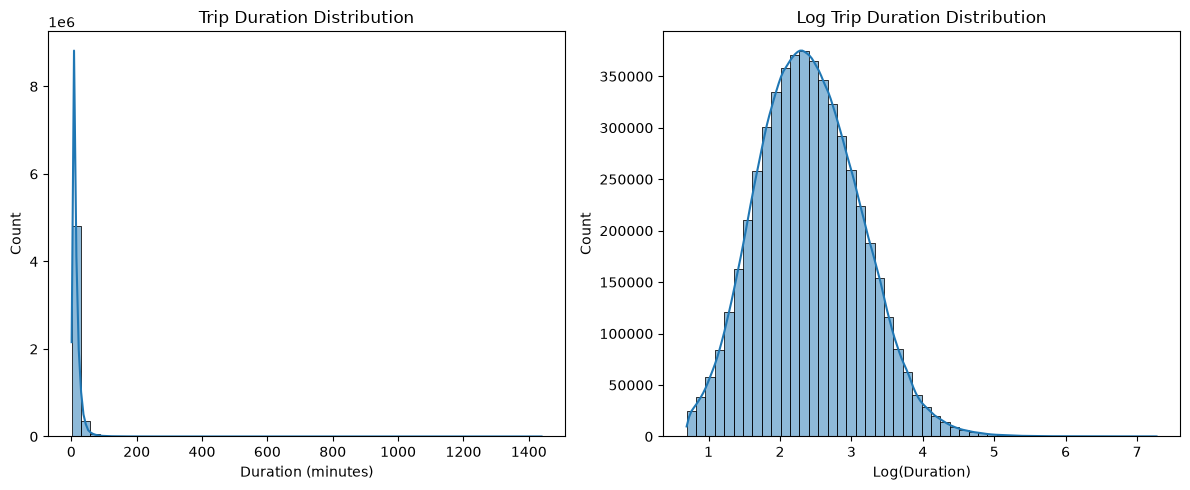

Average trip duration: 13.85 minutes
Median trip duration: 9.78 minutes


In [42]:
# 2.Trip Duration Distribution

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(
    final_df['trip_duration_min'],
    bins=50,
    kde=True
)
plt.title('Trip Duration Distribution')
plt.xlabel('Duration (minutes)')

plt.subplot(1, 2, 2)
sns.histplot(
    np.log1p(final_df['trip_duration_min']),
    bins=50,
    kde=True
)
plt.title('Log Trip Duration Distribution')
plt.xlabel('Log(Duration)')

plt.tight_layout()
plt.show()

print(
    "Average trip duration:",
    round(final_df['trip_duration_min'].mean(), 2),
    "minutes"
)

print(
    "Median trip duration:",
    round(final_df['trip_duration_min'].median(), 2),
    "minutes"
)

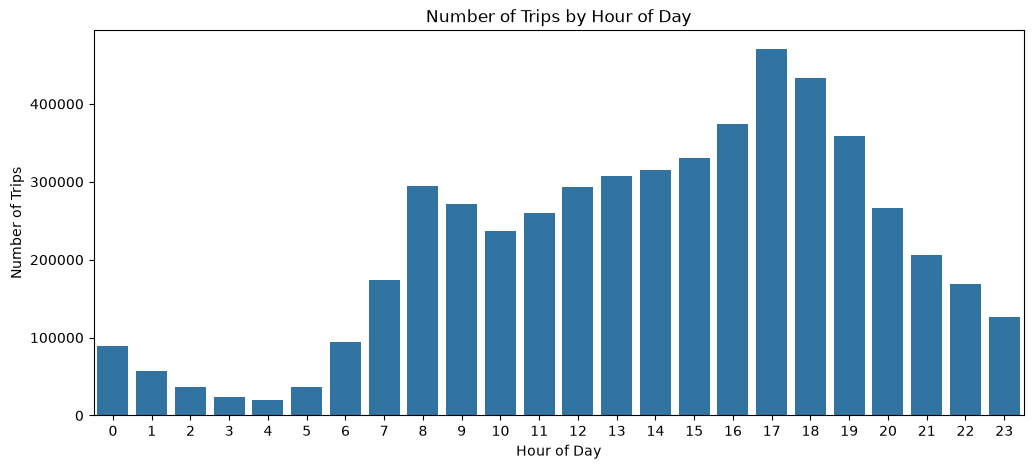

In [43]:
# 3.Trips by Hours of a Day
hourly_trips = final_df.groupby('hour').size()

plt.figure(figsize=(12, 5))

sns.barplot(
    x=hourly_trips.index,
    y=hourly_trips.values
)

plt.title('Number of Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(24))

plt.show()

C:\Users\Ritesh\AppData\Local\Temp\ipykernel_3728\1546080176.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_trips.index, y=daily_trips.values, palette='coolwarm')


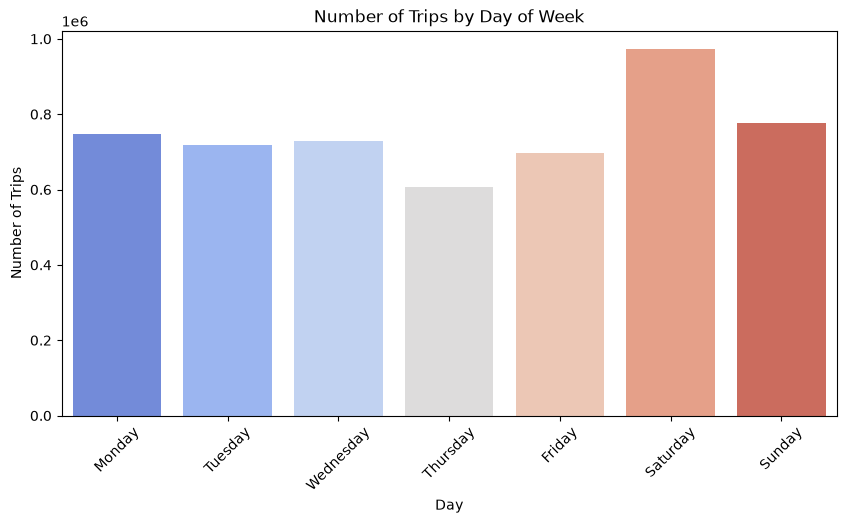

In [44]:
# 4. Trips by Day of Week

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_trips = final_df['day_of_week'].value_counts().reindex(order)

plt.figure(figsize=(10, 5))
sns.barplot(x=daily_trips.index, y=daily_trips.values, palette='coolwarm')
plt.title('Number of Trips by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()

C:\Users\Ritesh\AppData\Local\Temp\ipykernel_3728\3246109998.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, x='member_casual', palette='Set2')
C:\Users\Ritesh\AppData\Local\Temp\ipykernel_3728\3246109998.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x='member_casual', y='trip_duration_min', palette='Set2')


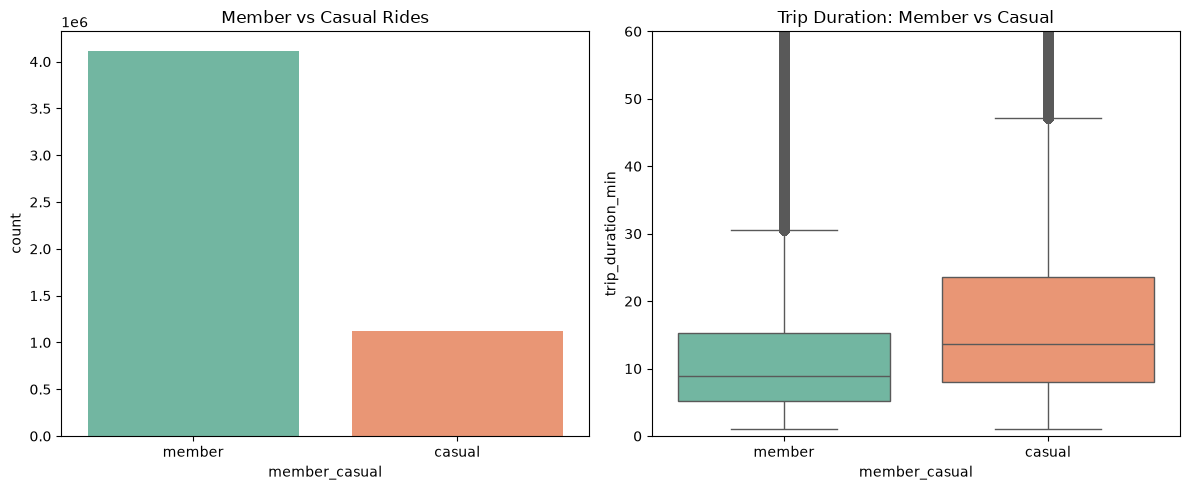

                    mean     median    count
member_casual                               
casual         20.009702  13.592083  1127127
member         12.169858   8.960000  4117846


In [45]:
# 5. Member vs Casual Comparison

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=final_df, x='member_casual', palette='Set2')
plt.title('Member vs Casual Rides')

plt.subplot(1, 2, 2)
sns.boxplot(data=final_df, x='member_casual', y='trip_duration_min', palette='Set2')

plt.title('Trip Duration: Member vs Casual')
plt.ylim(0, 60) # limit for better view

plt.tight_layout()
plt.show()

print(final_df.groupby('member_casual')['trip_duration_min'].agg(['mean', 'median',
'count']))

C:\Users\Ritesh\AppData\Local\Temp\ipykernel_3728\993526403.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_stations.index, x=top_stations.values, palette='magma')


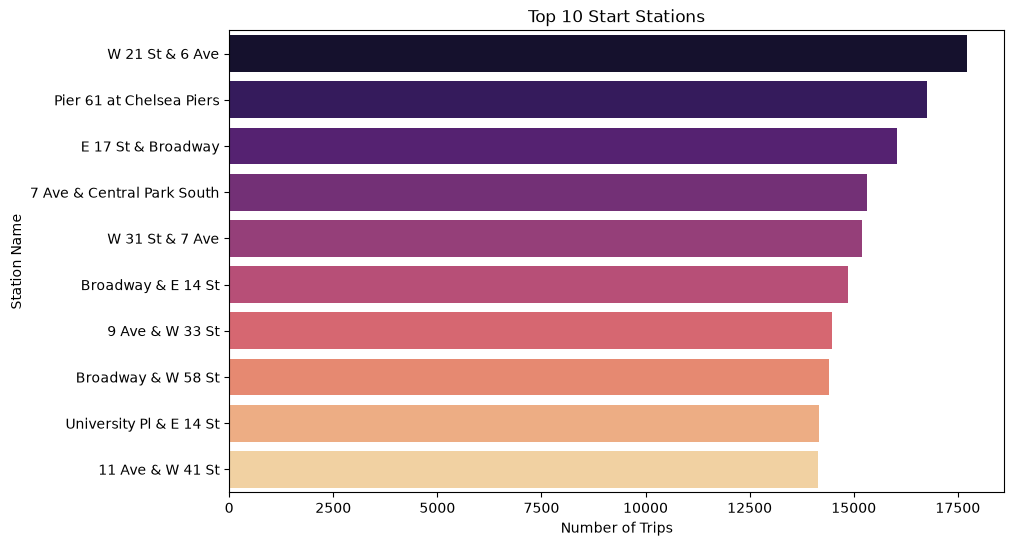

In [46]:
# 6. Top 10 Start Stations

top_stations = final_df['start_station_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=top_stations.index, x=top_stations.values, palette='magma')
plt.title('Top 10 Start Stations')
plt.xlabel('Number of Trips')
plt.ylabel('Station Name')
plt.show()

In [62]:
# 7. Weather Impact – Temperature vs Trips



C:\Users\Ritesh\AppData\Local\Temp\ipykernel_3728\1701272148.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, x='has_rain', palette='Blues')


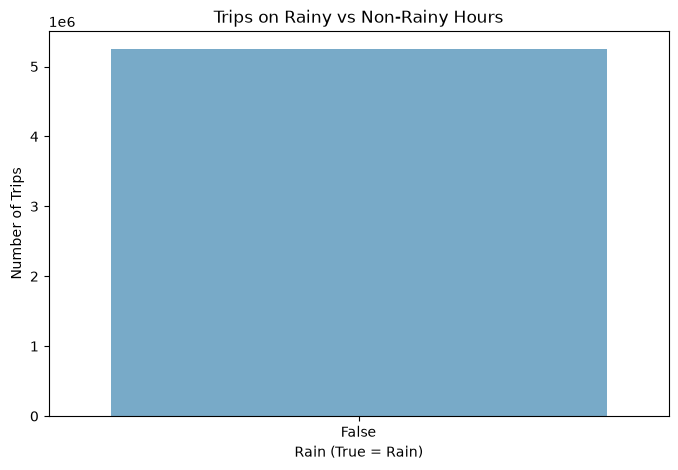

has_rain
False    13.854614
Name: trip_duration_min, dtype: float64


In [63]:
# 8. Precipitation Impact

final_df['has_rain'] = final_df['precipitation'] > 0

plt.figure(figsize=(8, 5))
sns.countplot(data=final_df, x='has_rain', palette='Blues')
plt.title('Trips on Rainy vs Non-Rainy Hours')
plt.xlabel('Rain (True = Rain)')
plt.ylabel('Number of Trips')
plt.show()

print(final_df.groupby('has_rain')['trip_duration_min'].mean())

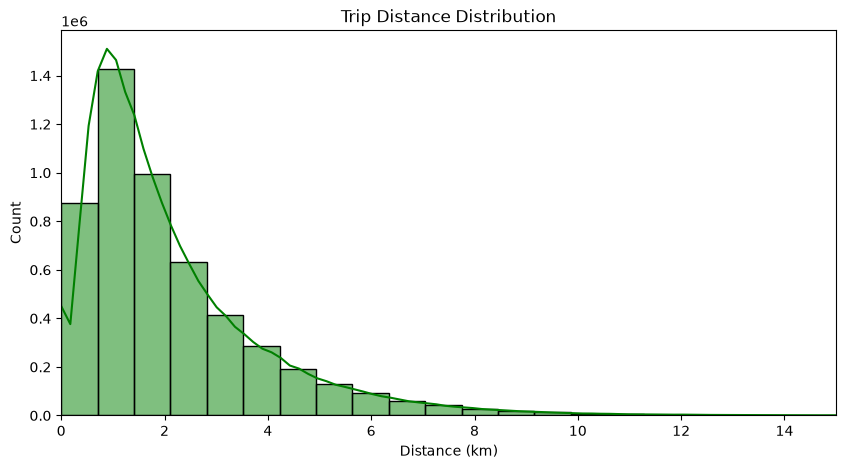

Average Distance: 2.14 km


In [64]:
# 9. Trip Distance Distribution

plt.figure(figsize=(10, 5))
sns.histplot(final_df['trip_distance_km'].dropna(), bins=50, kde=True, color='green')
plt.title('Trip Distance Distribution')
plt.xlabel('Distance (km)')
plt.xlim(0, 15)
plt.show()

print("Average Distance:", round(final_df['trip_distance_km'].mean(), 2), "km")

C:\Users\Ritesh\AppData\Local\Temp\ipykernel_3728\1291434822.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x='is_weekend', y='trip_duration_min', palette='pastel')


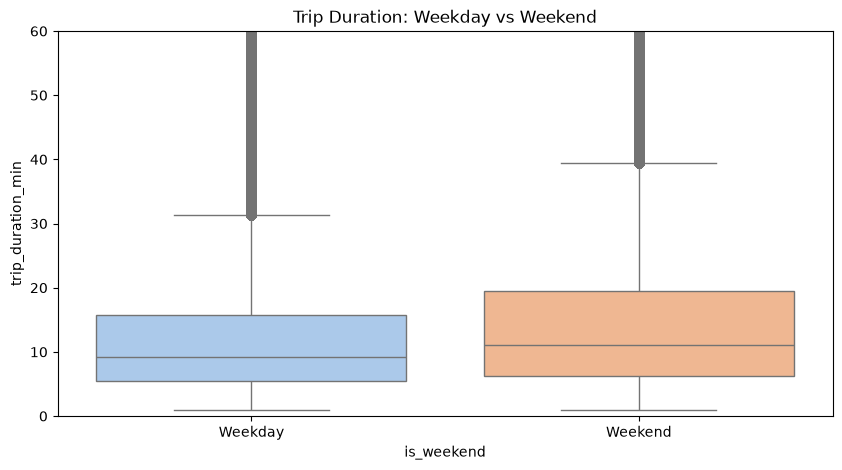

In [65]:
# 10. Weekend vs Weekday

plt.figure(figsize=(10, 5))
sns.boxplot(data=final_df, x='is_weekend', y='trip_duration_min', palette='pastel')
plt.title('Trip Duration: Weekday vs Weekend')
plt.ylim(0, 60)
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.show()

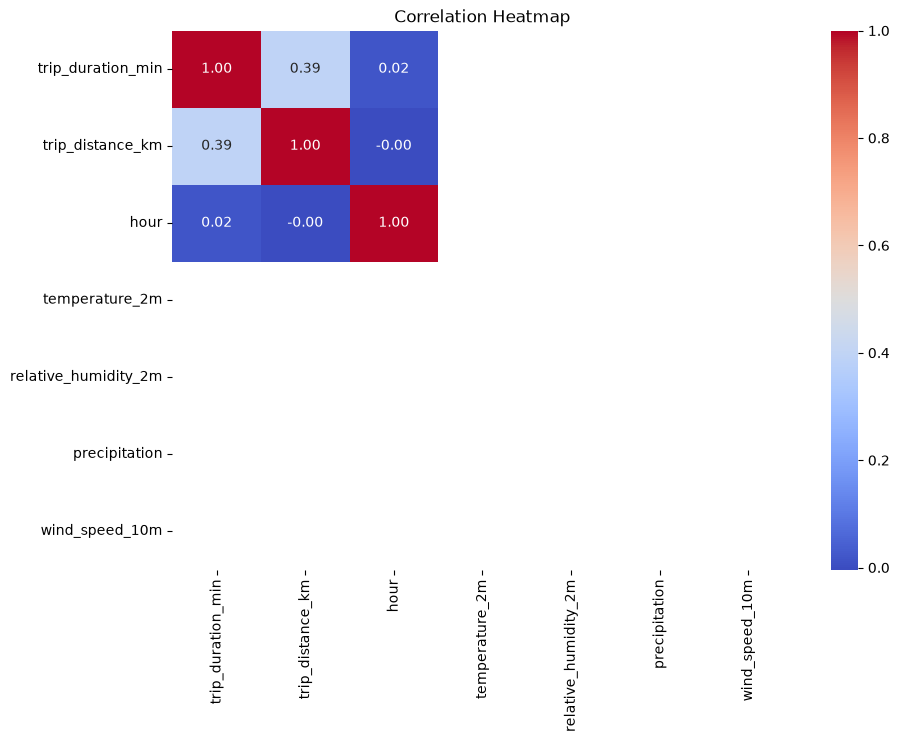

In [66]:
# 11. Correlation Heatmap (Important)

numeric_cols = ['trip_duration_min', 'trip_distance_km', 'hour',
'temperature_2m', 'relative_humidity_2m',
'precipitation', 'wind_speed_10m']

plt.figure(figsize=(10, 7))
sns.heatmap(final_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()